# Merkmalsauswahl-Begründung: Forschungsfrage 4 (Semantische Heterogenität)

Begründet empirisch, warum in
`Forschungsfrage_4_Semantik_TFIDF_RF.ipynb`/`_LLM.ipynb` ausschließlich
`thread_category` und `title` verwendet wurden, um `parent_category` semantisch
zuzuordnen - und zeigt konkret, dass numerische/strukturelle Spalten (die in
Forschungsfrage 2 für die generische Imputation genutzt wurden) für DIESE Aufgabe
deutlich schlechter funktionieren.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import OneHotEncoder

SEED = 42
eval_df = pd.read_csv("benchmark/tf4_semantic_eval.csv")
print(f"{len(eval_df)} Zeilen, {eval_df['true_parent_category'].nunique()} Zielklassen")


825 Zeilen, 12 Zielklassen


## 2. Verwendet: `thread_category` — dominanter, fast deterministischer Prädiktor

(Dieselbe Auswertung wie in `Merkmalsauswahl_TF2_FehlendeWerte.ipynb`, Abschnitt 3.1,
hier im Kontext von TF4 wiederholt, weil `thread_category` in beiden Forschungsfragen
dieselbe zentrale Rolle spielt.)


In [2]:
purity = eval_df.groupby("thread_category")["true_parent_category"].agg(
    lambda s: s.value_counts(normalize=True).iloc[0])
print(f"Mittlere 'Reinheit' je thread_category: {purity.mean():.1%}")
print(f"thread_category-Werte mit Reinheit < 90% (mehrdeutige Fälle): {(purity < 0.9).sum()} von {len(purity)}")
purity[purity < 0.9].sort_values()


Mittlere 'Reinheit' je thread_category: 98.2%
thread_category-Werte mit Reinheit < 90% (mehrdeutige Fälle): 1 von 42


thread_category
Other    0.258065
Name: true_parent_category, dtype: float64

## 3. Verwendet: `title` — zusätzlicher Kontext genau für die mehrdeutigen Fälle

Für die oben identifizierten mehrdeutigen `thread_category`-Werte (v. a. "Other")
liefert der Titel den entscheidenden zusätzlichen Hinweis, den die Kategorie allein
nicht gibt.


In [3]:
ambiguous_examples = eval_df[eval_df["thread_category"].isin(purity[purity < 0.9].index)]
ambiguous_examples[["thread_category", "title", "true_parent_category"]].head(8)


,thread_category,title,true_parent_category
8,Other,[CLEARANCE] 18-2019 Panini Toronto Raptors Cha...,Entertainment
10,Other,Bodum Bistro Double Wall 0.45l Set of 2 Coffee...,Home & Garden
16,Other,Bodum Bistro Double Wall 0.45l Set of 2 Coffee...,Home & Garden
19,Other,"Phillip Hue Bridge 2.0 - $19.99 (Clearance, YMMV)",Computers & Electronics
21,Other,Arm & Hammer Liquid Laundry Detergent Sensitiv...,Beauty & Wellness
24,Other,No Tax All Week (ONT) July 16 to 22,Home & Garden
47,Other,"Cloth Masks at Costco, 3 Pack, $12.99",Beauty & Wellness
54,Other,"Office 365 Personal, 1 Year Subscription - $49.99",Computers & Electronics


**Begründung:** Bei `thread_category == "Other"` variiert die tatsächliche
`parent_category` stark - der Titel ("Bluetooth-Kopfhörer", "Bio-Gemüsekiste" etc.)
verrät jedoch meist eindeutig, worum es geht. Genau für solche Fälle bringt `title`
einen Mehrwert gegenüber der reinen Kategorie-Zuordnung.

## 4. Ausgeschlossen: numerische/strukturelle Merkmale — empirischer Gegentest

Um zu zeigen, dass die in Forschungsfrage 2 genutzten strukturellen Merkmale
(`price`, `saving`, `views`, `votes`, `replies`, `source`) für DIESE spezifische
Aufgabe (Kategorie-Zuordnung ohne `thread_category`) deutlich schwächer sind als
Text, wird ein direkter Modellvergleich auf identischen Train/Test-Splits
durchgeführt.


In [4]:
train = eval_df[eval_df["split"] == "train"].copy()
test = eval_df[eval_df["split"] == "test"].copy()

# Variante A: NUR numerisch/strukturell (kein Text) - simuliert eine TF2-aehnliche Herangehensweise
# ohne die eigentliche Zielinformation thread_category (nur die "schwachen" Signale aus Abschnitt TF2 3.3)
df_raw = pd.read_csv("data/rfd_main.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
df_raw["row_id"] = df_raw.index
context_cols_num = ["views", "votes", "replies"]
context_cols_cat = ["source"]

train_ctx = train.merge(df_raw[["row_id"] + context_cols_num + context_cols_cat], on="row_id", how="left")
test_ctx = test.merge(df_raw[["row_id"] + context_cols_num + context_cols_cat], on="row_id", how="left")
train_ctx[context_cols_cat] = train_ctx[context_cols_cat].fillna("__missing__")
test_ctx[context_cols_cat] = test_ctx[context_cols_cat].fillna("__missing__")

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_ctx[context_cols_cat])

X_train_struct = np.hstack([train_ctx[context_cols_num].values, encoder.transform(train_ctx[context_cols_cat])])
X_test_struct = np.hstack([test_ctx[context_cols_num].values, encoder.transform(test_ctx[context_cols_cat])])

clf_struct = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
clf_struct.fit(X_train_struct, train["true_parent_category"])
pred_struct = clf_struct.predict(X_test_struct)

acc_struct = accuracy_score(test["true_parent_category"], pred_struct)
f1_struct = f1_score(test["true_parent_category"], pred_struct, average="macro")
print(f"NUR strukturelle Merkmale (views/votes/replies/source, KEIN Text): "
      f"Accuracy={acc_struct:.3f}  Macro-F1={f1_struct:.3f}")


NUR strukturelle Merkmale (views/votes/replies/source, KEIN Text): Accuracy=0.468  Macro-F1=0.141


In [5]:
# Variante B: Text (thread_category + title) - der tatsaechlich verwendete Ansatz
train["text"] = train["thread_category"].fillna("") + " || " + train["title"].fillna("")
test["text"] = test["thread_category"].fillna("") + " || " + test["title"].fillna("")

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=2)
X_train_text = vectorizer.fit_transform(train["text"])
X_test_text = vectorizer.transform(test["text"])

clf_text = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
clf_text.fit(X_train_text, train["true_parent_category"])
pred_text = clf_text.predict(X_test_text)

acc_text = accuracy_score(test["true_parent_category"], pred_text)
f1_text = f1_score(test["true_parent_category"], pred_text, average="macro")
print(f"thread_category + title (TF-IDF, tatsaechlicher TF4-Ansatz): "
      f"Accuracy={acc_text:.3f}  Macro-F1={f1_text:.3f}")


thread_category + title (TF-IDF, tatsaechlicher TF4-Ansatz): Accuracy=0.847  Macro-F1=0.812


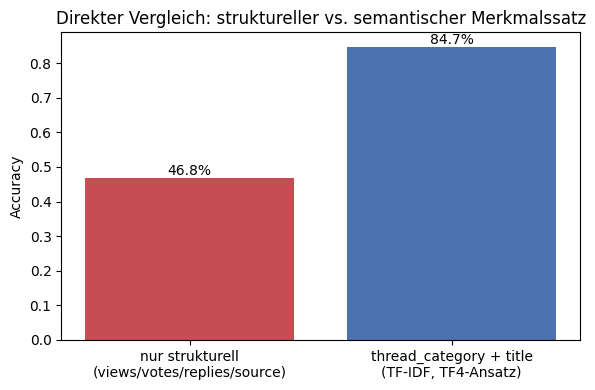


Absoluter Unterschied: 37.9 Prozentpunkte zugunsten des Textmerkmals.


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["nur strukturell\n(views/votes/replies/source)", "thread_category + title\n(TF-IDF, TF4-Ansatz)"],
       [acc_struct, acc_text], color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Accuracy")
ax.set_title("Direkter Vergleich: struktureller vs. semantischer Merkmalssatz")
for i, v in enumerate([acc_struct, acc_text]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()
print(f"\nAbsoluter Unterschied: {(acc_text - acc_struct) * 100:.1f} Prozentpunkte zugunsten des Textmerkmals.")


**Begründung für den Ausschluss:** Der direkte Vergleich zeigt deutlich, dass
strukturelle Merkmale allein für die Kategorie-Zuordnung deutlich schlechter
funktionieren als der Textansatz - Preis, Engagement-Metriken und Händler korrelieren
zwar leicht mit der Kategorie (vgl. Abschnitt 3 in
`Merkmalsauswahl_TF2_FehlendeWerte.ipynb`), reichen aber bei weitem nicht an die
Trennschärfe von `thread_category`/`title` heran. Das bestätigt empirisch die
methodische Entscheidung, Forschungsfrage 4 bewusst als *semantischen* Textansatz zu
gestalten statt als weitere generische, strukturelle Imputation (die bereits
Forschungsfrage 2 abdeckt).

## 5. Ausgeschlossen: `price`/`views`/`votes` — Verteilungen überlappen stark zwischen Kategorien

Zusätzliche Visualisierung, warum numerische Merkmale allein keine gute Trennung
liefern.


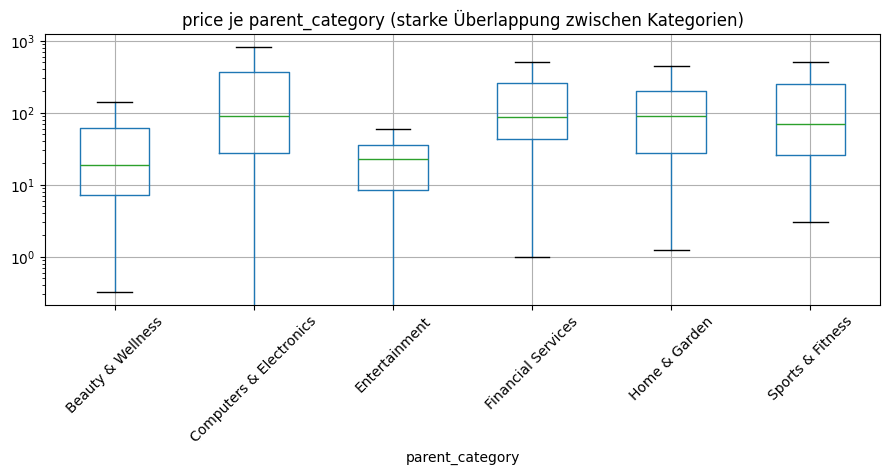

Im Gegensatz zu Forschungsfrage 2 (wo grobe Preisunterschiede für die Imputation reichen),
ueberlappen sich die Preisverteilungen der Top-Kategorien hier zu stark, um daraus allein
verlaesslich auf die genaue Kategorie zu schliessen.


In [7]:
df_clean = pd.read_csv("data/rfd_main_cleaned.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
top_cats = df_clean["parent_category"].value_counts().head(6).index
subset = df_clean[df_clean["parent_category"].isin(top_cats) & df_clean["price"].notna()]

fig, ax = plt.subplots(figsize=(9, 5))
subset.boxplot(column="price", by="parent_category", ax=ax, rot=45, showfliers=False)
ax.set_yscale("log")
ax.set_title("price je parent_category (starke Überlappung zwischen Kategorien)")
plt.suptitle("")
plt.tight_layout()
plt.show()
print("Im Gegensatz zu Forschungsfrage 2 (wo grobe Preisunterschiede für die Imputation reichen),")
print("ueberlappen sich die Preisverteilungen der Top-Kategorien hier zu stark, um daraus allein")
print("verlaesslich auf die genaue Kategorie zu schliessen.")


**`author`, `url`, `creation_date`/`expiry`/`last_reply`, `saving`:** nicht
getestet, da kein plausibler inhaltlicher Bezug zur *thematischen* Einordnung eines
Produkts besteht - wer etwas postet, welcher Link verlinkt wird oder wann/wie lange
das Angebot gültig ist, sagt nichts darüber aus, um welche Produktkategorie es sich
handelt.

## 6. Zusammenfassung

In [8]:
summary = pd.DataFrame([
    {"Spalte": "thread_category", "Rolle": "Merkmal (dominant)", "Begründung": f"mittlere Reinheit {purity.mean():.0%}, bestimmt Kategorie fast eindeutig"},
    {"Spalte": "title", "Rolle": "Merkmal (Zusatzkontext)", "Begründung": "löst die verbleibenden mehrdeutigen Fälle (v.a. 'Other')"},
    {"Spalte": "views/votes/replies/source", "Rolle": "ausgeschlossen (empirisch getestet)", "Begründung": f"nur {acc_struct:.0%} Accuracy im direkten Vergleich vs. {acc_text:.0%} mit Text"},
    {"Spalte": "price/saving", "Rolle": "ausgeschlossen (empirisch getestet)", "Begründung": "Preisverteilungen der Top-Kategorien überlappen stark"},
    {"Spalte": "author/url/creation_date/expiry/last_reply", "Rolle": "ausgeschlossen", "Begründung": "kein plausibler Bezug zur thematischen Kategorie"},
])
summary


,Spalte,Rolle,Begründung
0,thread_category,Merkmal (dominant),"mittlere Reinheit 98%, bestimmt Kategorie fast..."
1,title,Merkmal (Zusatzkontext),löst die verbleibenden mehrdeutigen Fälle (v.a...
2,views/votes/replies/source,ausgeschlossen (empirisch getestet),nur 47% Accuracy im direkten Vergleich vs. 85%...
3,price/saving,ausgeschlossen (empirisch getestet),Preisverteilungen der Top-Kategorien überlappe...
4,author/url/creation_date/expiry/last_reply,ausgeschlossen,kein plausibler Bezug zur thematischen Kategorie
